Question 1 - Extracting Tesla Stock Data Using yfinance 

In [83]:
import yfinance as yf

tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


Question 2 - Extracting Tesla Revenue Data Using Webscraping 

In [84]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data = requests.get(url).text
soup = BeautifulSoup(html_data, 'html.parser')
revenue_rows = []

In [85]:
tables = soup.find_all("table")
for table in tables:
    if "Tesla Quarterly Revenue" in str(table):
        for row in table.find_all("tr"):
            cols = row.find_all("td")
            if len(cols) == 2:
                date = cols[0].text.strip()
                revenue = cols[1].text.strip().replace("$", "").replace(",", "")
                revenue_rows.append({"Date": date, "Revenue": revenue})

tesla_revenue = pd.DataFrame(revenue_rows)
tesla_revenue["Date"] = pd.to_datetime(tesla_revenue["Date"])
tesla_revenue["Revenue"] = pd.to_numeric(tesla_revenue["Revenue"])
tesla_revenue.head()

,Date,Revenue
0,2022-09-30,21454.0
1,2022-06-30,16934.0
2,2022-03-31,18756.0
3,2021-12-31,17719.0
4,2021-09-30,13757.0


Question 3 - Extracting GameStop Stock Data Using yfinance

In [72]:
import yfinance as yf

gamestop = yf.Ticker("GME")
gme_data = gamestop.history(period="max")
gme_data.reset_index(inplace=True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691666,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716073,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


Question 4 - Extracting GameStop Revenue Data Using Webscraping

In [81]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

url_gme = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data = requests.get(url_gme).text
soup = BeautifulSoup(html_data, "html.parser")
revenue_rows = []

tables = soup.find_all("table")
for table in tables:
    if "GameStop Quarterly Revenue" in str(table):
        for row in table.find_all("tr"):
            cols = row.find_all("td")
            if len(cols) == 2:
                date = cols[0].text.strip()
                revenue = cols[1].text.strip().replace("$", "").replace(",", "")
                revenue_rows.append({"Date": date, "Revenue": revenue})

gme_revenue = pd.DataFrame(revenue_rows)
gme_revenue["Date"] = pd.to_datetime(gme_revenue["Date"])
gme_revenue["Revenue"] = pd.to_numeric(gme_revenue["Revenue"])
gme_revenue.head()

,Date,Revenue
0,2020-04-30,1021
1,2020-01-31,2194
2,2019-10-31,1439
3,2019-07-31,1286
4,2019-04-30,1548


Question 5 - Tesla Stock and Revenue Dashboard

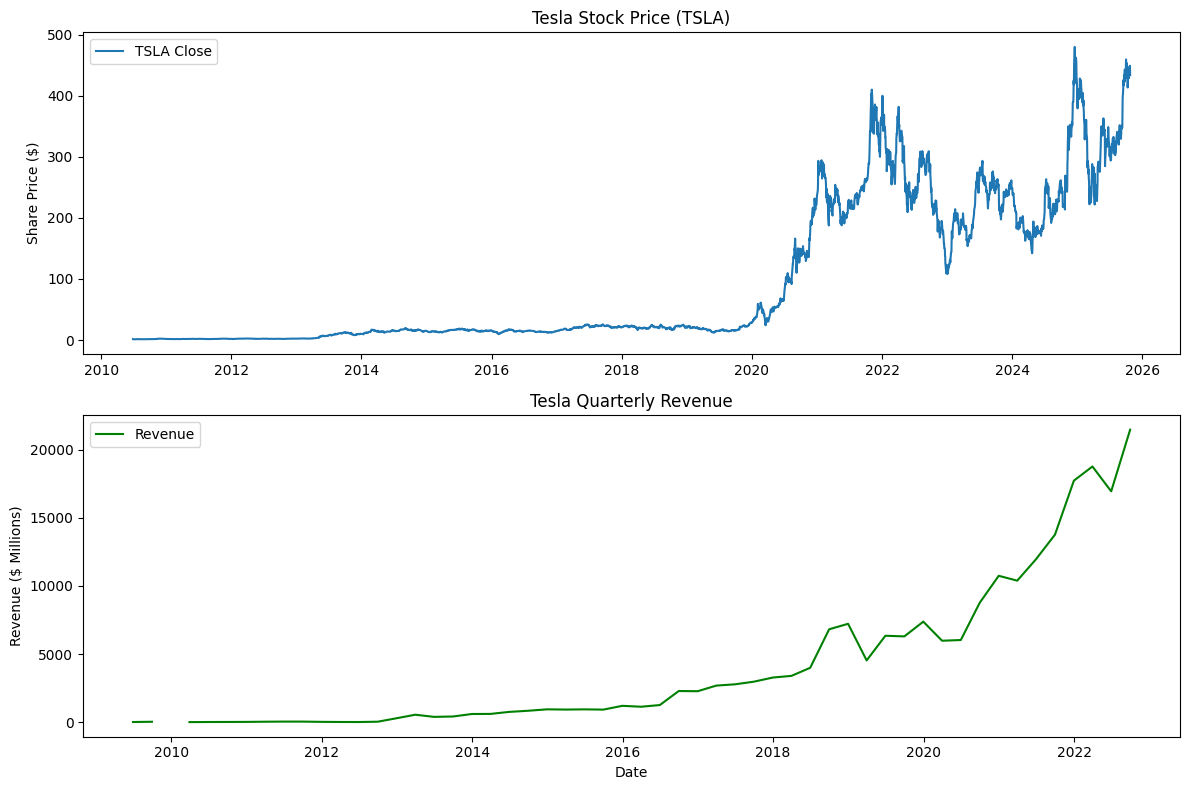

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.subplot(2, 1, 1)
plt.plot(tesla_data['Date'], tesla_data['Close'], label='TSLA Close')
plt.title('Tesla Stock Price (TSLA)')
plt.ylabel('Share Price ($)')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(tesla_revenue['Date'], tesla_revenue['Revenue'], color='green', label='Revenue')
plt.title('Tesla Quarterly Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue ($ Millions)')
plt.legend()

plt.tight_layout()
plt.show()

Question 6 - GameStop Stock and Revenue Dashboard

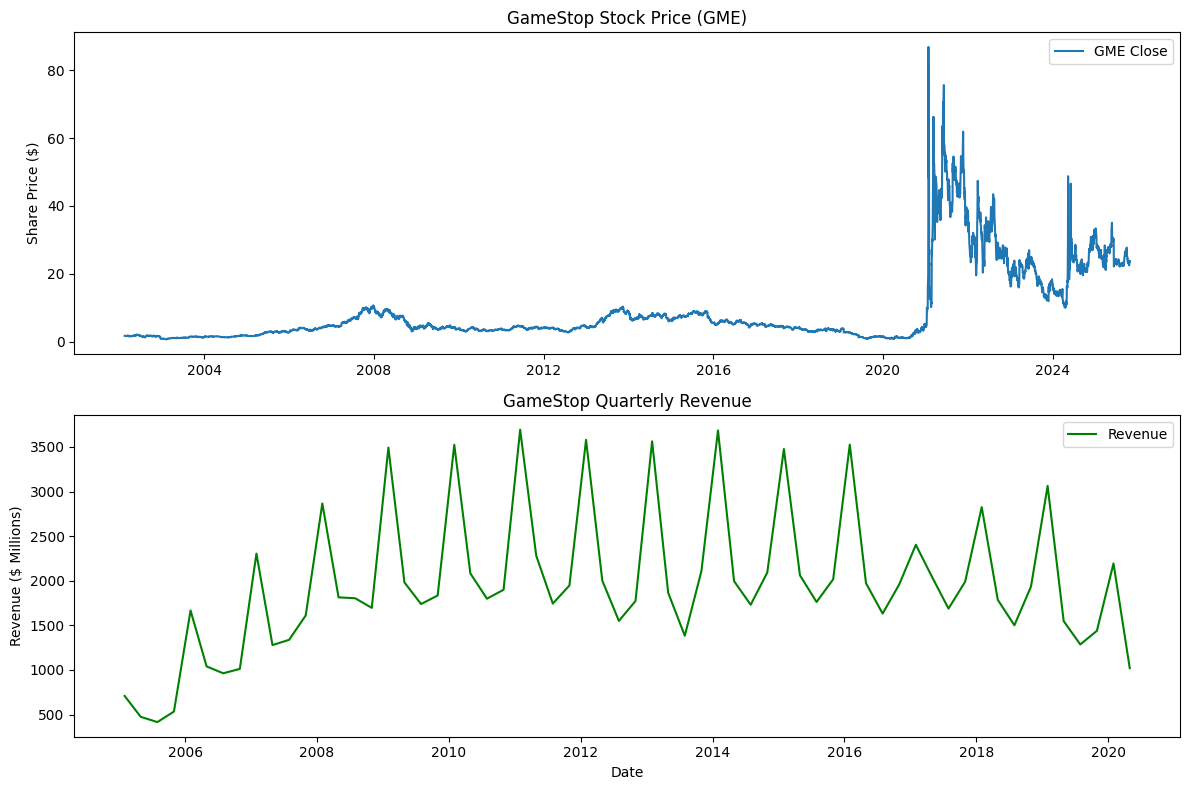

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.subplot(2, 1, 1)
plt.plot(gme_data['Date'], gme_data['Close'], label='GME Close')
plt.title('GameStop Stock Price (GME)')
plt.ylabel('Share Price ($)')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(gme_revenue['Date'], gme_revenue['Revenue'], color='green', label='Revenue')
plt.title('GameStop Quarterly Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue ($ Millions)')
plt.legend()

plt.tight_layout()
plt.show()